In [26]:
import pandas as pd
import geopandas as gpd

# Arquivo para atrelar cada imovel do ITBI a um Setor Censitario
### Calculando o valor do Imovel a partir do Valor Venal de Referencia, nao comercial

In [27]:
itbi = pd.read_excel('dados\IBTI_2023.xlsx')
# Garantir que 'N° do Cadastro (SQL)' seja string com 12 dígitos após o concat
itbi['N° do Cadastro (SQL)'] = itbi['N° do Cadastro (SQL)'].astype(str).str.zfill(11)
itbi.shape

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\ggsna\AppData\Local\Temp\ipykernel_29064\3828880195.py:1: SyntaxWarning: invalid escape sequence '\I'
  itbi = pd.read_excel('dados\IBTI_2023.xlsx')


(175459, 5)

In [28]:
itbi = pd.read_excel('dados\IBTI_completo.xlsx')
# Garantir que 'N° do Cadastro (SQL)' seja string com 12 dígitos após o concat
itbi['N° do Cadastro (SQL)'] = itbi['N° do Cadastro (SQL)'].astype(str).str.zfill(11)
itbi.shape

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\ggsna\AppData\Local\Temp\ipykernel_29064\2805786736.py:1: SyntaxWarning: invalid escape sequence '\I'
  itbi = pd.read_excel('dados\IBTI_completo.xlsx')


(624011, 7)

In [29]:
setores = gpd.read_file("dados\geo\SP_Malha_Preliminar_2022.shp")
sp = setores[setores["NM_MUN"] == "São Paulo"]
sp = sp.to_crs(epsg=4326)
sp.head()


<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\g'
C:\Users\ggsna\AppData\Local\Temp\ipykernel_29064\3600661627.py:1: SyntaxWarning: invalid escape sequence '\g'
  setores = gpd.read_file("dados\geo\SP_Malha_Preliminar_2022.shp")


,CD_SETOR,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,NM_MUN,CD_DIST,NM_DIST,...,NM_MICRO,CD_MESO,NM_MESO,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_CONCURB,NM_CONCURB,geometry
65763,355030801000001P,0.071797,3,Sudeste,35,São Paulo,3550308,São Paulo,355030801,Água Rasa,...,São Paulo,3515,Metropolitana de São Paulo,350001,São Paulo,3501,São Paulo,3550308,São Paulo/SP,"POLYGON ((-46.56954 -23.56918, -46.57016 -23.5..."
65764,355030801000002P,0.071902,3,Sudeste,35,São Paulo,3550308,São Paulo,355030801,Água Rasa,...,São Paulo,3515,Metropolitana de São Paulo,350001,São Paulo,3501,São Paulo,3550308,São Paulo/SP,"POLYGON ((-46.56806 -23.56521, -46.56786 -23.5..."
65765,355030801000003P,0.055681,3,Sudeste,35,São Paulo,3550308,São Paulo,355030801,Água Rasa,...,São Paulo,3515,Metropolitana de São Paulo,350001,São Paulo,3501,São Paulo,3550308,São Paulo/SP,"POLYGON ((-46.56619 -23.56605, -46.56632 -23.5..."
65766,355030801000004P,0.064905,3,Sudeste,35,São Paulo,3550308,São Paulo,355030801,Água Rasa,...,São Paulo,3515,Metropolitana de São Paulo,350001,São Paulo,3501,São Paulo,3550308,São Paulo/SP,"POLYGON ((-46.56876 -23.56856, -46.56863 -23.5..."
65767,355030801000005P,0.086820,3,Sudeste,35,São Paulo,3550308,São Paulo,355030801,Água Rasa,...,São Paulo,3515,Metropolitana de São Paulo,350001,São Paulo,3501,São Paulo,3550308,São Paulo/SP,"POLYGON ((-46.57121 -23.57005, -46.57056 -23.5..."


In [30]:
sp = sp[['CD_SETOR', 'geometry']]
sp.head()

,CD_SETOR,geometry
65763,355030801000001P,"POLYGON ((-46.56954 -23.56918, -46.57016 -23.5..."
65764,355030801000002P,"POLYGON ((-46.56806 -23.56521, -46.56786 -23.5..."
65765,355030801000003P,"POLYGON ((-46.56619 -23.56605, -46.56632 -23.5..."
65766,355030801000004P,"POLYGON ((-46.56876 -23.56856, -46.56863 -23.5..."
65767,355030801000005P,"POLYGON ((-46.57121 -23.57005, -46.57056 -23.5..."


In [31]:
lotes = gpd.read_file("dados\combinado\lotes_combinados.shp")
lotes.set_crs("EPSG:31983", inplace=True, allow_override=True)
lotes = lotes.to_crs(epsg=4326)
lotes.head()

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\ggsna\AppData\Local\Temp\ipykernel_29064\2399761421.py:1: SyntaxWarning: invalid escape sequence '\c'
  lotes = gpd.read_file("dados\combinado\lotes_combinados.shp")


,lo_setor,lo_quadra,lo_lote,lo_condomi,lo_tp_quad,lo_tp_lote,geometry
0,052,053,0015,00,F,F,"POLYGON ((-46.5795 -23.5644, -46.57945 -23.564..."
1,052,078,0070,00,F,F,"POLYGON ((-46.56997 -23.56665, -46.56998 -23.5..."
2,053,045,0038,00,F,F,"POLYGON ((-46.56357 -23.56735, -46.56354 -23.5..."
3,052,024,0147,00,F,F,"POLYGON ((-46.58057 -23.5734, -46.58064 -23.57..."
4,052,024,0148,00,F,F,"POLYGON ((-46.58057 -23.5734, -46.58061 -23.57..."


In [32]:
lotes['centroid'] = lotes['geometry'].centroid
lotes.head()

C:\Users\ggsna\AppData\Local\Temp\ipykernel_29064\3424562163.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lotes['centroid'] = lotes['geometry'].centroid


,lo_setor,lo_quadra,lo_lote,lo_condomi,lo_tp_quad,lo_tp_lote,geometry,centroid
0,052,053,0015,00,F,F,"POLYGON ((-46.5795 -23.5644, -46.57945 -23.564...",POINT (-46.57941 -23.56449)
1,052,078,0070,00,F,F,"POLYGON ((-46.56997 -23.56665, -46.56998 -23.5...",POINT (-46.56993 -23.56654)
2,053,045,0038,00,F,F,"POLYGON ((-46.56357 -23.56735, -46.56354 -23.5...",POINT (-46.56349 -23.56741)
3,052,024,0147,00,F,F,"POLYGON ((-46.58057 -23.5734, -46.58064 -23.57...",POINT (-46.58059 -23.57329)
4,052,024,0148,00,F,F,"POLYGON ((-46.58057 -23.5734, -46.58061 -23.57...",POINT (-46.58063 -23.57331)


In [33]:
lotes["N° do Cadastro (SQL)"] = lotes["lo_setor"].str.zfill(3) + \
                      lotes["lo_quadra"].str.zfill(3) + \
                      lotes["lo_lote"].str.zfill(4)
lotes.head()

,lo_setor,lo_quadra,lo_lote,lo_condomi,lo_tp_quad,lo_tp_lote,geometry,centroid,N° do Cadastro (SQL)
0,052,053,0015,00,F,F,"POLYGON ((-46.5795 -23.5644, -46.57945 -23.564...",POINT (-46.57941 -23.56449),0520530015
1,052,078,0070,00,F,F,"POLYGON ((-46.56997 -23.56665, -46.56998 -23.5...",POINT (-46.56993 -23.56654),0520780070
2,053,045,0038,00,F,F,"POLYGON ((-46.56357 -23.56735, -46.56354 -23.5...",POINT (-46.56349 -23.56741),0530450038
3,052,024,0147,00,F,F,"POLYGON ((-46.58057 -23.5734, -46.58064 -23.57...",POINT (-46.58059 -23.57329),0520240147
4,052,024,0148,00,F,F,"POLYGON ((-46.58057 -23.5734, -46.58061 -23.57...",POINT (-46.58063 -23.57331),0520240148


In [34]:
# Extrair os 10 primeiros dígitos do código SQL em ambas as tabelas
itbi['SQL_10_digitos'] = itbi['N° do Cadastro (SQL)'].astype(str).str[:9]
lotes['SQL_10_digitos'] = lotes['N° do Cadastro (SQL)'].astype(str).str[:9]

# Realizar o merge usando os 10 primeiros dígitos do SQL
itbi_merged = itbi.merge(
    lotes[['SQL_10_digitos', 'centroid']],
    on='SQL_10_digitos',
    how='left'
)

# Converter ITBI para GeoDataFrame usando o centróide
itbi_gdf = gpd.GeoDataFrame(itbi_merged, geometry='centroid', crs=lotes.crs)

# Garantir que os setores censitários estão no mesmo CRS
setores = setores.to_crs(itbi_gdf.crs)

# Realizar operação espacial para atribuir o setor censitário a cada imóvel
itbi_gdf['Setor_Censitario'] = gpd.sjoin(itbi_gdf, sp, how='left', predicate='within')['CD_SETOR']

itbi_gdf.head()

,N° do Cadastro (SQL),Bairro,CEP,Valor de Transação (declarado pelo contribuinte),Valor Venal de Referência,Proporção Transmitida (%),Área do Terreno (m2),SQL_10_digitos,centroid,Setor_Censitario
0,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43023 -23.51151),355030884000091P
1,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43033 -23.51131),355030884000091P
2,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43027 -23.51144),355030884000091P
3,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.4304 -23.51118),355030884000091P
4,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43037 -23.51125),355030884000091P


In [35]:
itbi_gdf.dropna(subset=['Setor_Censitario'], inplace=True)

In [36]:
itbi_gdf.head()

,N° do Cadastro (SQL),Bairro,CEP,Valor de Transação (declarado pelo contribuinte),Valor Venal de Referência,Proporção Transmitida (%),Área do Terreno (m2),SQL_10_digitos,centroid,Setor_Censitario
0,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43023 -23.51151),355030884000091P
1,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43033 -23.51131),355030884000091P
2,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43027 -23.51144),355030884000091P
3,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.4304 -23.51118),355030884000091P
4,13944000322,VL CURUCA,8032000.0,264000,15828870.0,0.2,11131,139440003,POINT (-46.43037 -23.51125),355030884000091P


In [37]:
# Converter a coluna 'Área do Terreno (m2)' para numérico, transformando não números em NaN
itbi_gdf['Área do Terreno (m2)'] = pd.to_numeric(itbi_gdf['Área do Terreno (m2)'], errors='coerce')

# Remover as linhas onde 'Área do Terreno (m2)' é NaN
itbi_gdf = itbi_gdf.dropna(subset=['Área do Terreno (m2)'])

itbi_gdf = itbi_gdf[itbi_gdf['Proporção Transmitida (%)'] >= 2]
itbi_gdf["preco/m2"] = itbi_gdf["Valor Venal de Referência"]/itbi_gdf["Área do Terreno (m2)"]

# SE FICAR MUITO ESTRANHO, VOLTAR AQUI E REVERTER PARA A LOGICA INICIAL

# itbi_gdf['preco/m2'] = itbi_gdf['Valor Venal de Referência']/itbi_gdf['Área do Terreno (m2)']

itbi_gdf.head()

,N° do Cadastro (SQL),Bairro,CEP,Valor de Transação (declarado pelo contribuinte),Valor Venal de Referência,Proporção Transmitida (%),Área do Terreno (m2),SQL_10_digitos,centroid,Setor_Censitario,preco/m2
7,06726500084,PARQUE VITORIA,2269090.0,800000,846885.0,100.0,210.0,067265000,POINT (-46.59508 -23.47015),355030882000117P,4032.785714
8,06726500084,PARQUE VITORIA,2269090.0,800000,846885.0,100.0,210.0,067265000,POINT (-46.59534 -23.4702),355030882000117P,4032.785714
9,06726500084,PARQUE VITORIA,2269090.0,800000,846885.0,100.0,210.0,067265000,POINT (-46.59481 -23.47025),355030882000117P,4032.785714
10,06726500084,PARQUE VITORIA,2269090.0,800000,846885.0,100.0,210.0,067265000,POINT (-46.59517 -23.47012),355030882000117P,4032.785714
296,05527400224,VILA CARRAO,3431020.0,1270000,534585.0,100.0,180.0,055274002,POINT (-46.53714 -23.55044),355030820000001P,2969.916667


In [38]:
# itbi_gdf_teste.sort_values(by='preco/m2', ascending=False).head()

In [39]:
# teste_setor = itbi_gdf_teste[itbi_gdf["Setor_Censitario"]== "355030866000170P"]
# teste_setor.head()

In [40]:
itbi_gdf = itbi_gdf.rename(columns={"Setor_Censitario": "CD_SETOR"})
itbi_gdf.head()

itbi_gdf.to_csv('itbi_sql.csv', index=False)

In [41]:
# Calcular o preço médio por m² e número de imóveis por setor
setor_stats = itbi_gdf.groupby('CD_SETOR').agg(
    preco_m2_medio=('preco/m2', 'mean'),  # Calcula a média de preço/m² por setor
    num_imoveis=('CD_SETOR', 'count')  # Conta o número de imóveis por setor
).reset_index()

setor_stats.head()



,CD_SETOR,preco_m2_medio,num_imoveis
0,355030801000001P,2673.621557,166
1,355030801000002P,2341.797679,212
2,355030801000003P,2238.769867,126
3,355030801000004P,2172.065809,54
4,355030801000005P,2351.617756,93


In [42]:
# Filtrar a base sp para incluir apenas setores presentes em setor_stats
sp_filtrado = sp[sp['CD_SETOR'].isin(setor_stats['CD_SETOR'])]

# Realizar o merge para incluir as estatísticas no GeoDataFrame filtrado
setor_final = sp_filtrado.merge(setor_stats, on='CD_SETOR', how='left')

# Exibir as primeiras linhas do GeoDataFrame final
setor_final.head()

,CD_SETOR,geometry,preco_m2_medio,num_imoveis
0,355030801000001P,"POLYGON ((-46.56954 -23.56918, -46.57016 -23.5...",2673.621557,166
1,355030801000002P,"POLYGON ((-46.56806 -23.56521, -46.56786 -23.5...",2341.797679,212
2,355030801000003P,"POLYGON ((-46.56619 -23.56605, -46.56632 -23.5...",2238.769867,126
3,355030801000004P,"POLYGON ((-46.56876 -23.56856, -46.56863 -23.5...",2172.065809,54
4,355030801000005P,"POLYGON ((-46.57121 -23.57005, -46.57056 -23.5...",2351.617756,93


In [43]:
# Opcional: Salvar o resultado em um GeoJSON
setor_final.to_file('dados_itbi_venal.geojson', driver='GeoJSON')

In [44]:
import folium

In [50]:
# Criar uma função para categorizar os preços
def categorizar_preco(preco):
    if preco <= 2000:
        return "0-2000"
    elif preco <= 4000:
        return "2001-4000"
    elif preco <= 6000:
        return "4001-6000"
    elif preco <= 8000:
        return "6001-8000"
    elif preco <= 10000:
        return "8001-10000"
    elif preco <= 12000:
        return "10001-12000"
    elif preco <= 14000:
        return "12001-14000"
    elif preco <= 16000:
        return "14001-16000"
    elif preco <= 18000:
        return "16001-18000"
    elif preco <= 20000:
        return "18001-20000"
    else:
        return "20001+"

# Aplicar a categorização à coluna `preco_m2`
setor_final['faixa_preco'] = setor_final['preco_m2_medio'].apply(categorizar_preco)

# Criar um dicionário de cores para as categorias
cor_categorias = {
    "0-2000": "#f7fbff",       # Azul claro
    "2001-4000": "#deebf7",
    "4001-6000": "#c6dbef",
    "6001-8000": "#9ecae1",
    "8001-10000": "#6baed6",
    "10001-12000": "#4292c6",
    "12001-14000": "#2171b5",
    "14001-16000": "#084594",  # Azul escuro
    "16001-18000": "#08306b",  # Azul ainda mais escuro
    "18001-20000": "#041f50",  # Azul quase preto
    "20001+": "#000033"        # Preto com tonalidade azulada
}

# Criar o mapa base
m = folium.Map(location=[-23.5505, -46.6333], zoom_start=11)

# Adicionar os setores ao mapa com cores personalizadas
for _, row in setor_final.iterrows():
    folium.GeoJson(
        row['geometry'],
        style_function=lambda feature, row=row: {
            'fillColor': cor_categorias[row['faixa_preco']],
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        },
        tooltip=f"Setor: {row['CD_SETOR']}<br>Preço/m²: R${row['preco_m2_medio']:.2f}<br>Faixa: {row['faixa_preco']}"
    ).add_to(m)

# Salvar o mapa como arquivo HTML
m.save("mapa_coropletico_itbi_venal.html")

print("Mapa coroplético salvo como 'mapa_coropletico_itbi_venal.html'. Abra no navegador para visualizar.")

Mapa coroplético salvo como 'mapa_coropletico_itbi_venal.html'. Abra no navegador para visualizar.


In [46]:
print("terminou de rodar!!")

terminou de rodar!!


In [47]:
setor_final.sort_values(by='preco_m2_medio', ascending=False).head()

,CD_SETOR,geometry,preco_m2_medio,num_imoveis,faixa_preco
765,355030807000211P,"POLYGON ((-46.64706 -23.56745, -46.64708 -23.5...",42241.752586,8,20001+
764,355030807000210P,"POLYGON ((-46.64706 -23.56745, -46.64675 -23.5...",29763.772314,34,20001+
4180,355030826000070P,"POLYGON ((-46.65785 -23.55385, -46.65755 -23.5...",27822.092593,2,20001+
8240,355030845000287P,"POLYGON ((-46.66299 -23.55742, -46.66329 -23.5...",27617.590707,3,20001+
728,355030807000155P,"POLYGON ((-46.64629 -23.56338, -46.64632 -23.5...",23680.891304,2,20001+


C:\Users\ggsna\AppData\Local\Temp\ipykernel_29064\2844436603.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=setor_final.sort_values(by='preco_m2_medio', ascending=False).head(10), x='preco_m2_medio', y='CD_SETOR', palette='viridis')


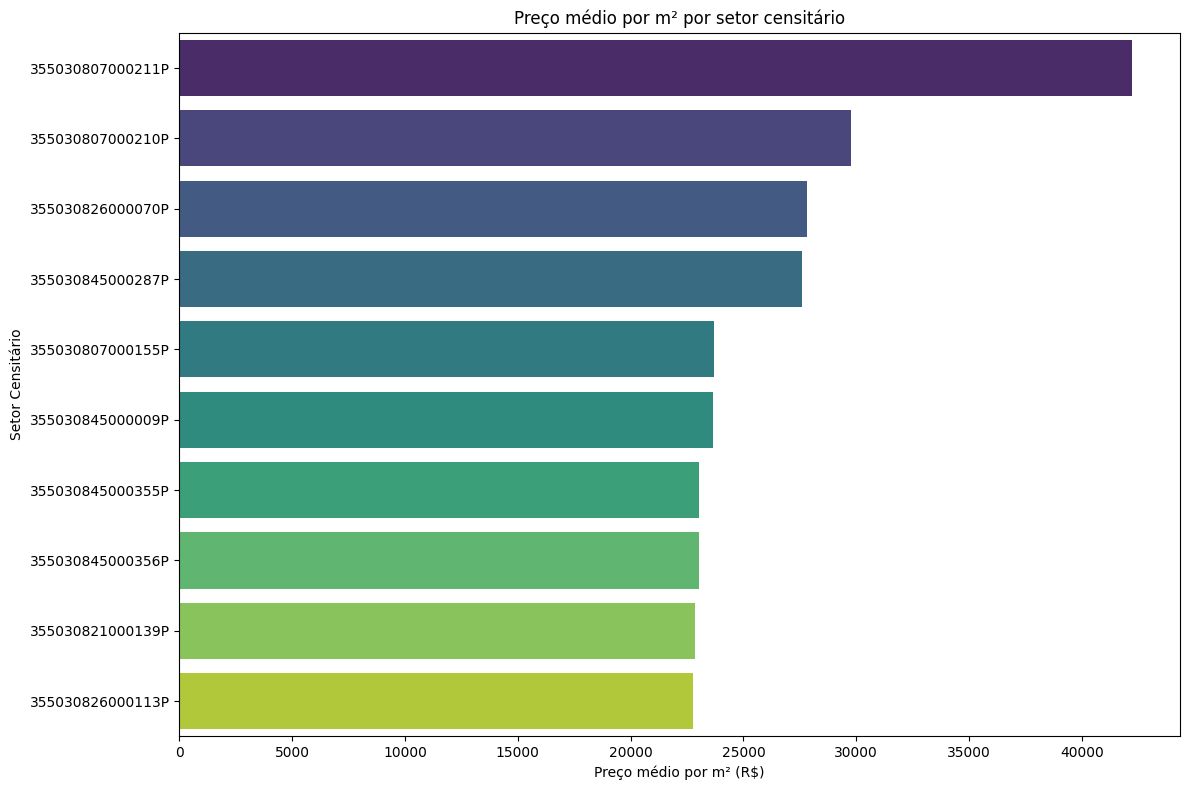

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar um gráfico de barras horizontais com o preco_m2_medio
plt.figure(figsize=(12, 8))
sns.barplot(data=setor_final.sort_values(by='preco_m2_medio', ascending=False).head(10), x='preco_m2_medio', y='CD_SETOR', palette='viridis')
plt.xlabel('Preço médio por m² (R$)')
plt.ylabel('Setor Censitário')
plt.title('Preço médio por m² por setor censitário')
plt.tight_layout()
plt.show()